<a href="https://colab.research.google.com/github/sk27110/basic_ml_hse/blob/task_4/homework_04_gradient_descent.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Основы машинного обучения, ПАДиИИ

## НИУ ВШЭ, 2024-25 учебный год

# Домашнее задание 4. Градиентный спуск

Задание выполнил(а):

    Кочетков Александр
    

В этом задании две части - теоретическая и практическая.  

Теорию нужно набирать, используя LaTex. А практику - используя Python!


> Максимальный балл за домашнее задание - 10

## Общая информация

__Внимание!__  

* Домашнее задание выполняется самостоятельно
* Не допускается помощь в решении домашнего задания от однокурсников или третьих лиц. «Похожие» решения считаются плагиатом, и все задействованные студенты — в том числе и те, у кого списали, — не могут получить за него больше 0 баллов
* Использование в решении домашнего задания генеративных моделей (ChatGPT и так далее) за рамками справочной и образовательной информации для генерации кода задания — считается плагиатом, и такое домашнее задание оценивается в 0 баллов

**Примечание**

В каждой части оцениваются как код, **так и ответы на вопросы.** Вопросы подсвечены синим цветом.

Если нет одного и/или другого, то часть баллов за соответствующее задание снимается.

## Часть 1 (теоретическая)

### Задание 1 (**1.5 балла**)

В случае одномерной Ridge-регрессии минимизируется функция со штрафом:
$$Q(w) = (y-xw)^T(y-xw)+\lambda w^2,$$
где $\lambda$ - положительный параметр, штрафующий функцию за слишком большие значения $w$.

1)  (**0.5 балла**) Найдите производную $\nabla_w Q(w)$, выведите формулу для оптимального $w$.

2) (**0.5 балла**) Найдите вторую производную $\nabla^2_w Q(w)$. Убедитесь, что мы оказались в точке минимума.

3) (**0.5 балла**) Выпишите шаг градиентного спуска в матричном виде.

1)
$∇_wQ(w) = -2x^T(y-xw) + 2λw  $ \\
$-2x^T(y-xw) + 2λw = 0$ \\
$ -x^Ty + x^Txw + λw = 0 $ \\
$ w(x^Tx + λ) = x^Ty $ \\
$ w = \frac{x^Ty}{x^Tx+λ} $ \\
$ w = (x^Tx + λ)^{-1}x^Ty $ \\

2) $∇_wQ(w) = -2x^Ty + 2x^Txw + 2λw  $ \\
$∇^2_wQ(w) = 2x^Tx + 2λ ≥ 0$ -- точка минимума

3) $ w_{k+1} = w_{k} - \alpha ∇_wQ(w) = w_{k} + \alpha(2x^T(y-xw_k) - 2λw)  $


## Часть 2 (практическая)

### Задание 2 (**1 балл**)

Дана функция: $$f(x) = x\cdot sin(5x) + 0.1 \cdot x^2$$

Для этой функции:

- [ ] Реализуйте (или возьмите рассмотренный на занятии) метод градиетного спуска с условием остановки `stop=1e^-6` и шагом `eta=0.001`. **Градиетный спуск обязательно должен сохранять траекторию движения.**
- [ ] Задайте стартовые точки x0, равные 0, 0.5, 1
- [ ] Реализуйте нахождение точек минимума и максимума функции $f(x)$ (для нахождения максимума нам нужно в направлении градиента, а не антиградиента)
- [ ] Проанализируйте результаты. Предположите, с чем они связаны. Ответьте на вопросы:
    - Чему равны значения экстремумов?
    - При старте из какой начальной точки найденные экстремумы совпадут?




In [1]:
import math

# Функция и её производная
def f(x):
  value = x*math.sin(5*x) + 0.1*x**2
  return value


def df(x):
    value = 5*x*math.cos(5*x) + math.sin(5*x) + 0.2*x
    return value

# Градиентный спуск
def gradient_descent(f, df, x0, eta, max_iter=1000, tol=1e-6):

    x = x0
    path = [x0]
    for i in range(max_iter):
      grad = df(x)
      x_new = x - eta*grad
      if abs(x_new - x) < tol:
        break
      x = x_new
      path.append(x)

    return x, path

# Поиск экстремумов
def find_points(f, df, x0, eta, max_iter=1000, tol=1e-6):
    min = []
    for starting_x in x0:
      found_x = gradient_descent(f, df, starting_x, eta, max_iter, tol)[0]
      grad2 = df(found_x)
      if grad2!=0:
        min.append({starting_x: found_x})

    max = []
    for starting_x in x0:
      found_x = gradient_descent(f, lambda x: -df(x), starting_x, eta, max_iter, tol)[0]
      grad2 = -df(found_x)
      if grad2!=0:
        max.append({starting_x: found_x})


    return {'min': min, 'max': max}


x0 = [0, 0.5, 1]
stop = 1e-6
eta = 0.001

extremes = find_points(f=f, df=df, x0=x0, eta=eta, tol=stop)

print("Минимумы:", extremes['min'])
print("Максимумы:",extremes['max'])

Минимумы: [{0.5: 0.975060876515715}, {1: 0.9751376478508075}]
Максимумы: [{0.5: 0.41185702181234396}, {1: 1.6035293061150784}]


Точки минимума: 0.975 \\
Точки маскимума: 0.411, 1.603 \\

При старте из точек 0.5 и 1 минимумы совпали

### Задание 3 (**0.5 балла**)

Напишите функцию, вычисляющую значение весов в линейной регрессии по точной (аналитически найденной) формуле.

In [2]:
import numpy as np


def ols_solution(X, y):
    X = np.array(X)
    if np.all(X[:, 0] != 1):
        X = np.c_[np.ones(X.shape[0]), X]
    XTX = X.T @ X
    XTX_inv = np.linalg.pinv(XTX)  # Псевдообратная для устойчивости
    w = XTX_inv @ X.T @ y

    return w.flatten()

### Задание 5 (**1 балл**)
Модифицируйте метод градиентного спуска с семинара так, чтобы это теперь был метод стохастического градиентного спуска.

In [3]:
def compute_cost(X, y, theta):
    m = len(y)

    cost = (1./m) * (np.linalg.norm(X @ theta - y) ** 2)
    return cost


def stochastic_gradient_descent(X, y, learning_rate, iterations):
    X = np.hstack((np.ones((X.shape[0], 1)), X))
    params = np.random.rand(X.shape[1])
    m = X.shape[0]
    cost_track = np.zeros((iterations, 1))

    for i in range(iterations):
        idx = np.random.randint(0, m)
        x_i = X[idx]
        y_i = y[idx]
        error = x_i.dot(params) - y_i
        gradient = 2 * error * x_i
        params = params - learning_rate * gradient
        cost_track[i] = compute_cost(X, y, params)

    return cost_track, params

### Задание 6 (**3 балла**)
* **(0 баллов)**. Скопируйте метод градиентного спуска из семинара в этот ноутбук.

* **(0.5 балла)**. Обучите линейную регрессию на данных, сгенерированных ниже, тремя методами (по точной формуле, с помощью GD и с помощью SGD) на данных для задачи регрессии (см. код). Для GD и SGD используйте learning_rate = 0.01, iterations=10000.

* **(0.5 балла)**. С помощью каждого метода сделайте предсказание (на всех данных), вычислите качество предсказания r2 (from sklearn.metrics import r2_score). Для получения предсказания можете использовать функцию predict с семинара.


Ответьте на следующие вопросы (каждый вопрос - **0.5 балла**):

1) все ли методы справились с нахождением минимума? если нет, то почему какой-то из методов не справился?

2) сравните время работы методов (используйте библиотеку time): замеряйте время работы соответствующей написанной вами функции.

3) для методов GD и SGD нарисуйте графики (для каждого свой) зависимости ошибки (loss) от номера итерации.

4) какой метод успешнее всего справился с задачей? (т.е. r2 наибольший).

In [4]:
from sklearn.datasets import make_regression
import pandas as pd
import numpy as np

X, y, _ = make_regression(n_samples=100000,   # number of samples
                          n_features=10,      # number of features
                          n_informative=8,    # number of useful features
                          noise=100,          # bias and standard deviation of the guassian noise
                          coef=True,          # true coefficient used to generated the data
                          random_state=123)

X = pd.DataFrame(data=X, columns=np.arange(0, X.shape[1]))
X[10] = X[6] + X[7] + np.random.random()*0.01

In [5]:
import time


def gradient_descent(X, y, learning_rate, iterations):

    X = np.hstack((np.ones((X.shape[0], 1)), X))
    params = np.random.rand(X.shape[1])

    m = X.shape[0]

    cost_track = np.zeros((iterations,1))

    for i in range(iterations):
        params = params - 2./m * learning_rate * (X.T @ ((X @ params) - y))
        cost_track[i] = compute_cost(X, y, params)

    return cost_track, params


learing_rate = 0.01
iterations=10000


In [7]:
start_time = time.time()
gd_cost_track, gd_params = gradient_descent(X, y, learning_rate=learing_rate, iterations=iterations)
end_time = time.time()
execution_time = end_time - start_time
print(f"Время обучения gd: {execution_time} секунд")

Время обучения gd: 20.7038094997406 секунд


In [8]:
start_time = time.time()
sgd_cost_track, sgd_params = stochastic_gradient_descent(X, y, learning_rate=learing_rate, iterations=iterations)
end_time = time.time()
execution_time = end_time - start_time
print(f"Время обучения sgd: {execution_time} секунд")

Время обучения sgd: 11.978529930114746 секунд


In [10]:
start_time = time.time()
ols_params = ols_solution(X,y)
end_time = time.time()
execution_time = end_time - start_time
print(f"Время обучения аналитического решения: {execution_time} секунд")

Время обучения аналитического решения: 0.04113054275512695 секунд


In [12]:
from sklearn.metrics import r2_score

def predict(X, params):
    X = np.hstack((np.ones((X.shape[0], 1)), X))
    return X @ params

gd_pred = predict(X ,gd_params)
sgd_pred = predict(X ,sgd_params)
ols_pred = predict(X ,ols_params)

gd_err = r2_score(y, gd_pred)
sgd_err = r2_score(y, sgd_pred)
ols_err = r2_score(y, ols_pred)

print(gd_err)
print(sgd_err)
print(ols_err)

0.7554626185750483
0.7392433490135984
0.7554626185750483


С нахождением минимума не очень хорошо справился SGD. Возможно, он просто не успел сойтись к минимуму, так как для сходимости ему надо больше итераций, чем для обычного GD.

Быстрее всего обучилось обычное аналитическое решение. это связано с тем, что его сложность

O(D^2N + D^3), D=11, N=100000. Т.е. сложность O(10^7).

Сложность GD: O(KDN) = O(10^4*10^5*10) = O(10^10)

Сложность SGD меньше, чем у GD, но мы на каждой итерации вычисляем ошибку на всей выборке, поэтому сложность сравнима с обычным GD

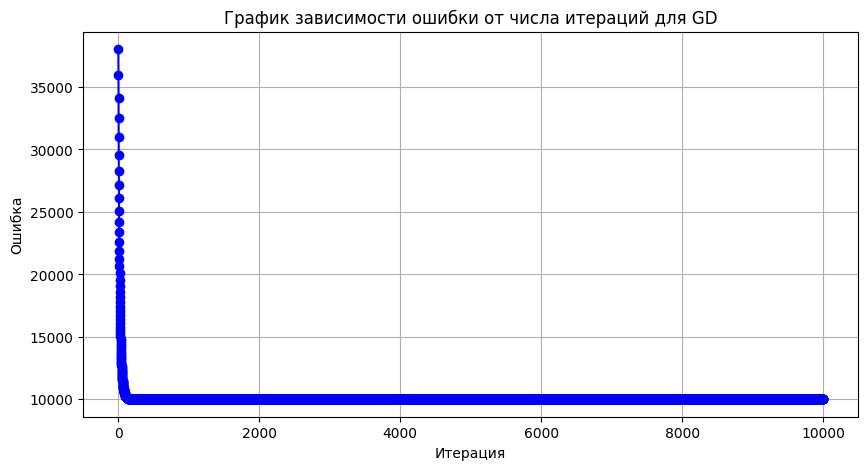

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(gd_cost_track, marker='o', linestyle='-', color='b')
plt.title("График зависимости ошибки от числа итераций для GD")
plt.xlabel("Итерация")
plt.ylabel("Ошибка")
plt.grid(True)
plt.show()

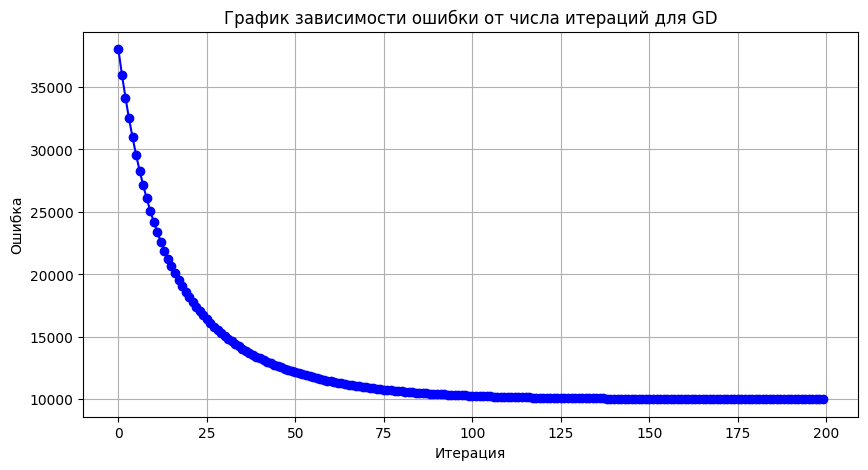

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(gd_cost_track[:200], marker='o', linestyle='-', color='b')
plt.title("График зависимости ошибки от числа итераций для GD")
plt.xlabel("Итерация")
plt.ylabel("Ошибка")
plt.grid(True)
plt.show()

Можно сделать вывод, что GD сходится уже через 100-150 итераций.

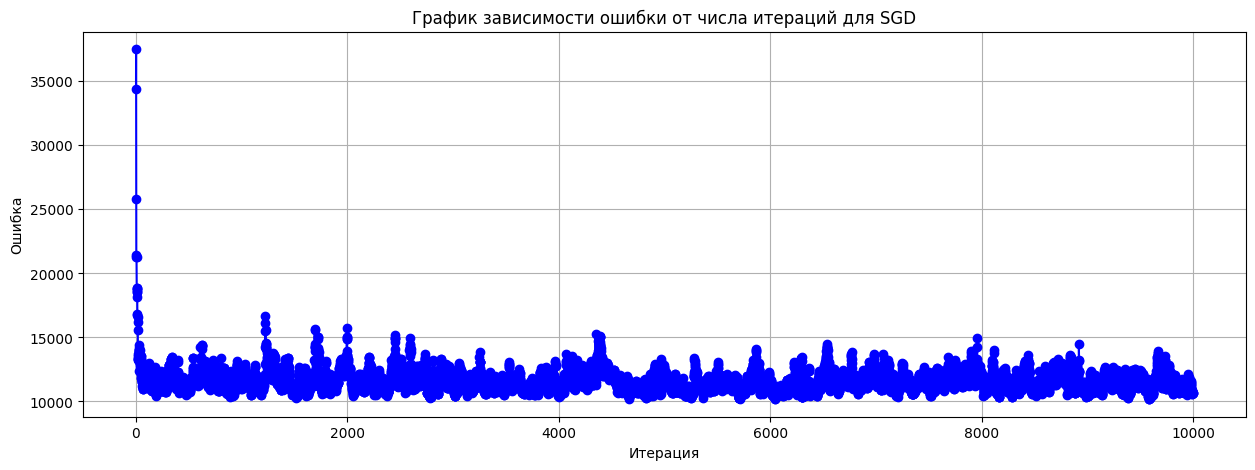

In [15]:
plt.figure(figsize=(15, 5))
plt.plot(sgd_cost_track, marker='o', linestyle='-', color='b')
plt.title("График зависимости ошибки от числа итераций для SGD")
plt.xlabel("Итерация")
plt.ylabel("Ошибка")
plt.grid(True)
plt.show()

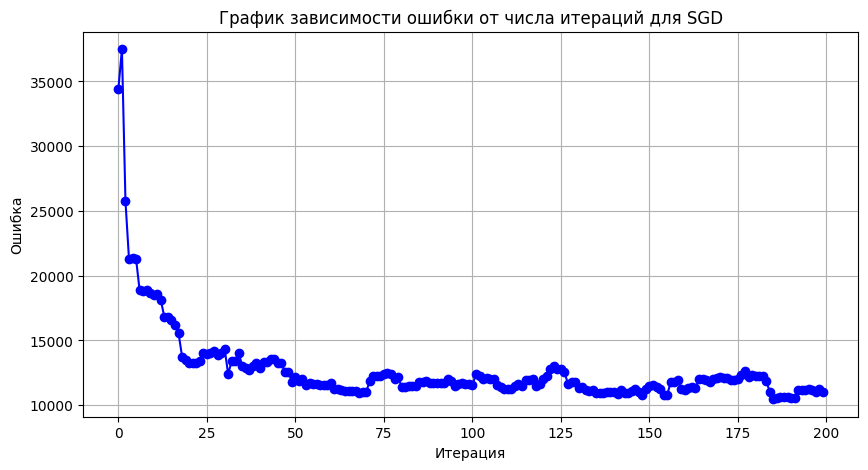

In [16]:
plt.figure(figsize=(10, 5))
plt.plot(sgd_cost_track[:200], marker='o', linestyle='-', color='b')
plt.title("График зависимости ошибки от числа итераций для SGD")
plt.xlabel("Итерация")
plt.ylabel("Ошибка")
plt.grid(True)
plt.show()

А вот SGD сходится плохо. Большие колебания ошибки. Видимо, этого числа итераций не хватило для хорошей сходимости. Теперь понятно, зачем придумали методы с выбором батчей вместо использования одного объекта, результат на них наверняка был бы лучше.

Одинаково хорошо справились обычный GD и аналитическое решение, но из-за небольшого числа фич в наших данных и наверное из-за хорошей оптимизации в numpy аналитическое решение справилось на порядки быстрее.

### Задание 7 (**1.5 балла**)

* **(0.5 балла)**. Добавьте в функцию из задания 5 L2-регуляризацию и, соответственно, новый аргумент - коэффициент при регуляризаторе.

* **(1 балл)**. На сгенерированных выше данных обучите модифицированный алгоритм SGD с регуляризацией: в цикле перебирайте значения коэффициента регуляризации от 0.1 до 1 с шагом 0.1. Для каждого значения обучите модель и сделайте предсказание, выведите значение r2. Для какого значения коэффициента регуляризации получилось наилучшее качество r2, почему?

In [20]:


import numpy as np

def compute_cost(X, y, theta, lambda_reg=0):
    m = len(y)
    cost = (1. / m) * (np.linalg.norm(X @ theta - y) ** 2) + (lambda_reg / (2 * m)) * np.sum(theta[1:]**2)
    return cost


def stochastic_gradient_descent_l2(X, y, learning_rate, iterations, lambda_reg=0):
    X = np.hstack((np.ones((X.shape[0], 1)), X))
    params = np.random.rand(X.shape[1])
    m = X.shape[0]
    cost_track = np.zeros((iterations, 1))

    for i in range(iterations):
        idx = np.random.randint(0, m)
        x_i = X[idx]
        y_i = y[idx]
        error = x_i.dot(params) - y_i
        gradient = 2 * error * x_i
        reg_gradient = lambda_reg * params
        reg_gradient[0] = 0
        gradient += reg_gradient
        params -= learning_rate * gradient
        cost_track[i] = compute_cost(X, y, params, lambda_reg)

    return cost_track, params

In [25]:

for lambda_reg in np.arange(0.1, 1.01, 0.1):
  lambda_reg = round(lambda_reg, 1)
  cost_track, params = stochastic_gradient_descent_l2(X=X, y=y, learning_rate=learing_rate, iterations=iterations, lambda_reg=lambda_reg)
  y_pred = predict(X, params)
  print(f'lambda={lambda_reg}, r2_score={r2_score(y, y_pred)}')


lambda=0.1, r2_score=0.7165330402111214
lambda=0.2, r2_score=0.7151095877114837
lambda=0.3, r2_score=0.6783774858652878
lambda=0.4, r2_score=0.7336841655784483
lambda=0.5, r2_score=0.7163737044195205
lambda=0.6, r2_score=0.6989165091093787
lambda=0.7, r2_score=0.6524401973082667
lambda=0.8, r2_score=0.6676647788457104
lambda=0.9, r2_score=0.644442545431673
lambda=1.0, r2_score=0.6442075266080027


Лучшее значение получилось при lambda=0.4 и в целом видно, что при маленьких lambda значения лучше, чем при больших. Это может говорить о том, что некоторые коэффиценты в нашей модели должны быть большими для хорошого качества модели, так как данные мы не нормировали.

### Задание 8 (**2 балла**)

Реализуйте на выбор одну из оптимизаций градиентного спуска - Momentum или  AdaGrad. Необходимые выкладки вы можете подсмотреть [здесь](https://education.yandex.ru/handbook/ml/article/optimizaciya-v-ml).

In [ ]:
def modified_grad_descent(X, y, learning_rate, iterations): # добавьте в аргументы также специфические для метода оптимизации гиперпараметры
    # your code here

## Бонус

### Задание 9 (**0.5 балла**)

Существует [метод Ньютона](https://en.wikipedia.org/wiki/Newton%27s_method_in_optimization) (метод второго порядка) для поиска минимума функции.

Известно, что методы второго порядка точнее, чем методы первого порядка (то есть те, которые используют только первую производную для оптимизации). Как вы думаете, почему в оптимизации функций потерь все формулы используют только производные первого порядка? Почему не используют метод Ньютона?

`Ваш ответ здесь`

## Заключительная часть

Вы молодцы, это было непросто!


Поделитесь впечатлениями о задании:

    (ваши эмоции от домашней работы)

P.S Удачного кодинга!  
Пейте ристретто, пишите эффективный Python!!